In [37]:
#Task1 This script will generate a file named streamify_churn.csv.

import pandas as pd
import numpy as np
import csv

def generate_churn_dataset(num_records=1000, filename="streamify_churn.csv"):
    """
    Generates a synthetic dataset for a video streaming service's customer churn prediction task.

    Args:
        num_records (int): The number of customer records to generate.
        filename (str): The name of the output CSV file.
    """
    np.random.seed(42) #reproducibility

    # Feature Generation
    user_ids = range(1001, 1001 + num_records)
    ages = np.random.randint(18, 70, size=num_records)
    subscription_plans = np.random.choice(['Basic', 'Standard', 'Premium'], size=num_records, p=[0.5, 0.3, 0.2])
    monthly_watch_hours = np.random.uniform(5, 250, size=num_records)
    devices_used = np.random.randint(1, 6, size=num_records)
    customer_support_calls = np.random.randint(0, 10, size=num_records)
    used_promo = np.random.choice([True, False], size=num_records, p=[0.4, 0.6])
    last_active_days_ago = np.random.randint(0, 90, size=num_records)


    churn_score = (
        (last_active_days_ago * 0.08) +
        (customer_support_calls * 0.2) +
        (250 - monthly_watch_hours) * 0.01 -
        (devices_used * 0.1) -
        (ages * 0.01)
    )

    churn_score += np.random.normal(0, 1.5, size=num_records)

    churn_threshold = np.percentile(churn_score, 75)
    will_churn = churn_score > churn_threshold

    #Dataframe
    data = {
        'user_id': user_ids,
        'age': ages,
        'subscription_plan': subscription_plans,
        'monthly_watch_hours': np.round(monthly_watch_hours, 2),
        'devices_used': devices_used,
        'customer_support_calls': customer_support_calls,
        'used_promo': used_promo,
        'last_active_days_ago': last_active_days_ago,
        'will_churn': will_churn
    }
    df = pd.DataFrame(data)

    # Save to CSV
    df.to_csv(filename, index=False, quoting=csv.QUOTE_NONNUMERIC)
    print(f"Successfully generated '{filename}' with {num_records} records.")
    print("\n Data Preview ")
    print(df.head())
    print("\n Churn Distribution")
    print(df['will_churn'].value_counts(normalize=True))


if __name__ == "__main__":
    generate_churn_dataset(num_records=1000)



Successfully generated 'streamify_churn.csv' with 1000 records.

 Data Preview 
   user_id  age subscription_plan  monthly_watch_hours  devices_used  \
0     1001   56          Standard               102.83             1   
1     1002   69             Basic                42.34             4   
2     1003   46             Basic               248.16             3   
3     1004   32             Basic               232.12             1   
4     1005   60             Basic               137.29             4   

   customer_support_calls  used_promo  last_active_days_ago  will_churn  
0                       2       False                    67       False  
1                       5       False                    79        True  
2                       5        True                    63       False  
3                       7        True                    29       False  
4                       1        True                    35       False  

 Churn Distribution
will_churn
False    0.

/var/folders/3n/95p0kb2100xgmlhc37cr8ghr0000gn/T/ipykernel_38473/4124154890.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="will_churn", palette="pastel")


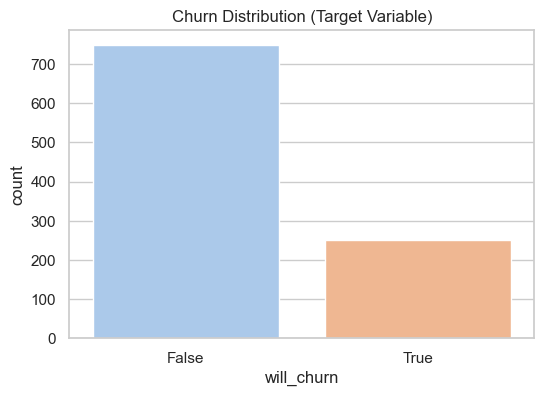

In [41]:
#Visualization: Target variable distribution Created a bar chart to see the distribution of the target variable (will_churn)
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="will_churn", palette="pastel")
plt.title("Churn Distribution (Target Variable)")
plt.show()


In [35]:
#Task 2: Data Exploration and Visualization:

import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

sns.set(style="whitegrid")

df= pd.read_csv("streamify_churn.csv")

#Performed an initial analysis (.info(), .describe(), .isnull().sum()) to understand the data's structure.

print("~~~~~~~~Initial info~~~~~~~~")
print(df.info())

print("~~~~~~~~Statistical Summary~~~~~~~~")
print(df.describe())

print("\n~~~~~~~~Missing Values~~~~~~~~")
print(df.isnull().sum())

~~~~~~~~Initial info~~~~~~~~
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   user_id                 1000 non-null   int64  
 1   age                     1000 non-null   int64  
 2   subscription_plan       1000 non-null   object 
 3   monthly_watch_hours     1000 non-null   float64
 4   devices_used            1000 non-null   int64  
 5   customer_support_calls  1000 non-null   int64  
 6   used_promo              1000 non-null   bool   
 7   last_active_days_ago    1000 non-null   int64  
 8   will_churn              1000 non-null   bool   
dtypes: bool(2), float64(1), int64(5), object(1)
memory usage: 56.8+ KB
None
~~~~~~~~Statistical Summary~~~~~~~~
           user_id         age  monthly_watch_hours  devices_used  \
count  1000.000000  1000.00000          1000.000000   1000.000000   
mean   1500.500000    43.81900  

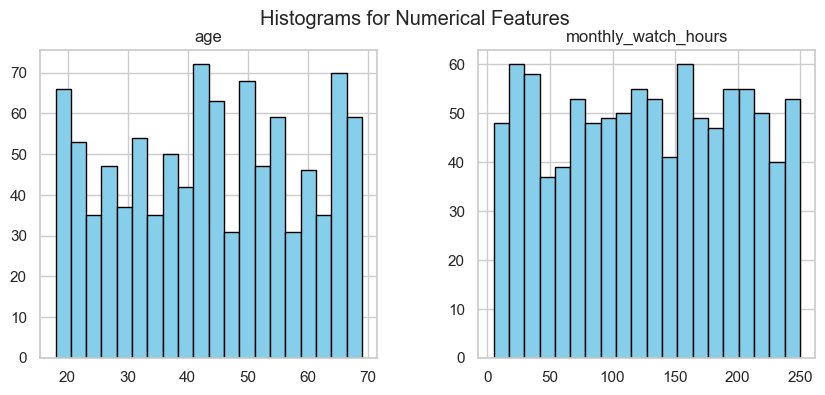

In [15]:
# Task 2 Histograms for numerical features
numerical_features = ["age", "monthly_watch_hours"]

df[numerical_features].hist(bins=20, figsize=(10,4), color="skyblue", edgecolor="black")
plt.suptitle("Histograms for Numerical Features")
plt.show()

/var/folders/3n/95p0kb2100xgmlhc37cr8ghr0000gn/T/ipykernel_38473/1929679215.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="subscription_plan", palette="muted")


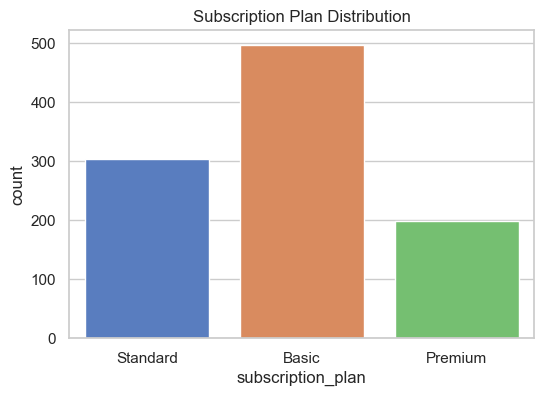

In [18]:
# Task 2: Bar chart for categorical feature
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="subscription_plan", palette="muted")
plt.title("Subscription Plan Distribution")
plt.show()

In [43]:
churn_counts = df['will_churn'].value_counts()
print(churn_counts)

churn_percent = df['will_churn'].value_counts(normalize=True)*100
print(churn_percent)

will_churn
False    750
True     250
Name: count, dtype: int64
will_churn
False    75.0
True     25.0
Name: proportion, dtype: float64


The class distribution of 75:25 does not require aggressive balancing techniques such as SMOTE. However, model performance will be evaluated using Recall and F1-Score in addition to Accuracy to ensure that churning customers are correctly identified.


In [49]:
#checking the imbalance if any 
churn_ratio = df['will_churn'].value_counts(normalize=True)

print(f"Non-Churn: {churn_ratio[False]*100:.1f}%")
print(f"Churn: {churn_ratio[True]*100:.1f}%")

Non-Churn: 75.0%
Churn: 25.0%


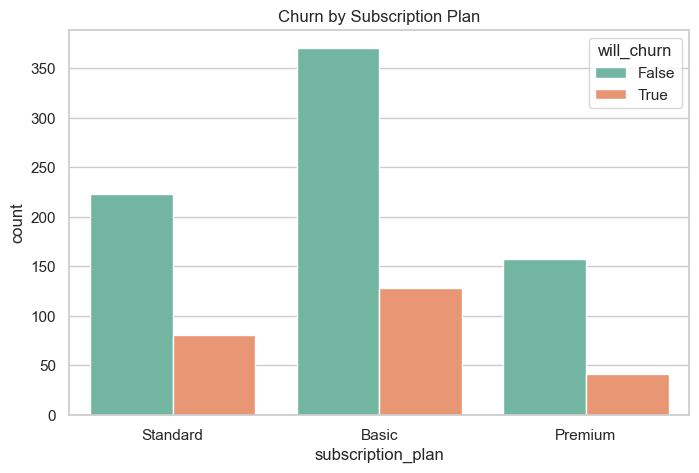

In [51]:
#understanding churn by subscription plan

plt.figure(figsize=(8,5))
sns.countplot(data=df,
              x='subscription_plan',
              hue='will_churn',
              palette='Set2')

plt.title("Churn by Subscription Plan")
plt.show()

Customers on the Basic plan show a higher proportion of churn compared to Premium users.
This suggests that lower-tier plans may have lower customer engagement or satisfaction.

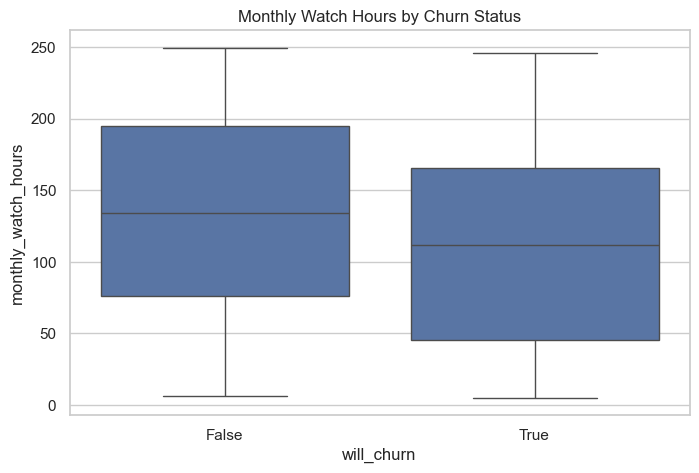

In [45]:
#understanding churn vs monthly watch hours
plt.figure(figsize=(8,5))
sns.boxplot(data=df,
            x='will_churn',
            y='monthly_watch_hours')

plt.title("Monthly Watch Hours by Churn Status")
plt.show()

Customers who churn generally exhibit lower monthly watch hours compared to retained customers, suggesting that reduced platform engagement is associated with a higher likelihood of churn.

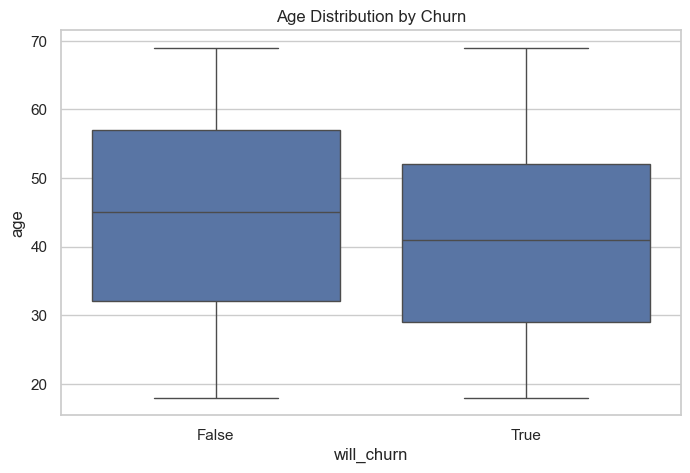

In [56]:
#age distribution by churn
plt.figure(figsize=(8,5))
sns.boxplot(data=df,
            x='will_churn',
            y='age')

plt.title("Age Distribution by Churn")
plt.show()

Age does not appear to be a major driver of churn because the distributions for churned and retained customers overlap considerably. Therefore, age may have limited predictive power compared to behavioral variables such as monthly watch hours.


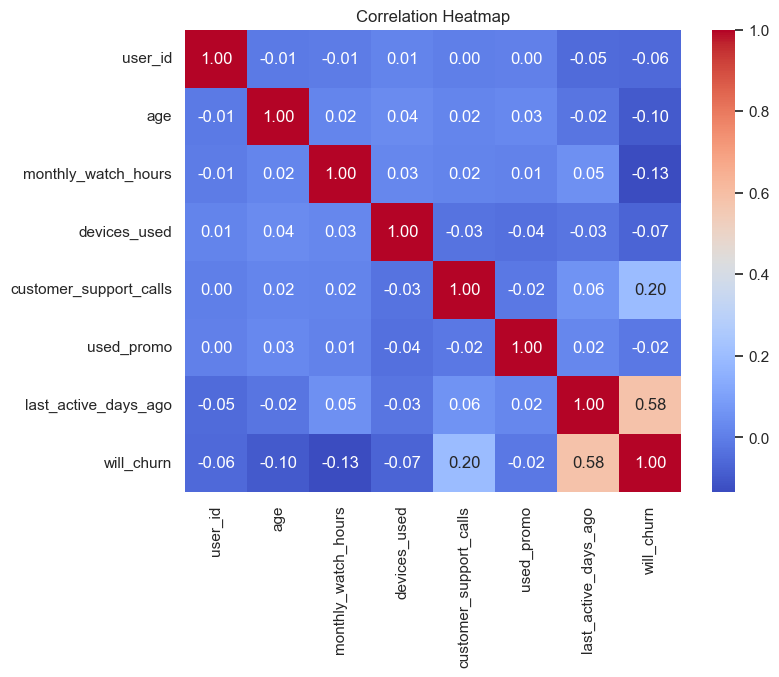

In [20]:
# Task 2:  Correlation heatmap for numerical features
plt.figure(figsize=(8,6))
corr_matrix = df.corr(numeric_only=True)  # ensures only numeric columns are considered
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

Strongest Predictor: last_active_days_ago (0.58),Customers who have been inactive for many days are much more likely to churn.

In [22]:
# Task 3: Data Preprocessing 

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

# 1. Handle categorical data (One-Hot Encoding)
df_encoded = pd.get_dummies(df, columns=["subscription_plan"], drop_first=True)

print("\nAfter Encoding:")
print(df_encoded.head())

# 2. Separate features (X) and target (y)
X = df_encoded.drop("will_churn", axis=1)
y = df_encoded["will_churn"]


# 3. Feature scaling for numerical columns
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Why scaling?
# - Ensures all numerical features have similar ranges
# - Prevents features with large values from dominating the model
# - Helps models like Logistic Regression and SVM converge faster

# 4. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)


After Encoding:
   user_id  age  monthly_watch_hours  devices_used  customer_support_calls  \
0     1001   56               102.83             1                       2   
1     1002   69                42.34             4                       5   
2     1003   46               248.16             3                       5   
3     1004   32               232.12             1                       7   
4     1005   60               137.29             4                       1   

   used_promo  last_active_days_ago  will_churn  subscription_plan_Premium  \
0       False                    67       False                      False   
1       False                    79        True                      False   
2        True                    63       False                      False   
3        True                    29       False                      False   
4        True                    35       False                      False   

   subscription_plan_Standard  
0            

In [26]:
# Task 5 : Model Evaluation


from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# === Predictions ===
print("Making predictions on the test set...\n")
y_pred_log = log_reg.predict(X_test)
y_pred_rf = rf_clf.predict(X_test)

# === Evaluation function ===
def evaluate_model(y_true, y_pred, model_name):
    print(f"=== {model_name} Evaluation ===")
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print("\nDetailed Classification Report:")
    print(classification_report(y_true, y_pred))
    print("-" * 40)

# Evaluate both models
evaluate_model(y_test, y_pred_log, "Logistic Regression")
evaluate_model(y_test, y_pred_rf, "Random Forest")

# === Justification ===
print("\nJustification:")
print("In churn prediction, Recall is usually the most important metric.")
print("Reason: A False Negative (predicting 'stay' when the customer will churn) means missing the chance to re-engage and retain them.")
print("This is typically more costly than a False Positive, which might lead to offering a retention deal to a customer who would have stayed anyway.\n")
# Select best model
print("Based on Recall, the model with the higher Recall score is preferred for Streamify.")

# Model selection
if recall_score(y_test, y_pred_rf) > recall_score(y_test, y_pred_log):
    print("\nBest Model: Random Forest - Higher recall, better at identifying customers likely to churn.")
else:
    print("\nBest Model: Logistic Regression - Comparable recall with simpler model.")

Making predictions on the test set...

=== Logistic Regression Evaluation ===
Accuracy : 0.8650
Precision: 0.7091
Recall   : 0.7800
F1 Score : 0.7429

Detailed Classification Report:
              precision    recall  f1-score   support

       False       0.92      0.89      0.91       150
        True       0.71      0.78      0.74        50

    accuracy                           0.86       200
   macro avg       0.82      0.84      0.83       200
weighted avg       0.87      0.86      0.87       200

----------------------------------------
=== Random Forest Evaluation ===
Accuracy : 0.8600
Precision: 0.7292
Recall   : 0.7000
F1 Score : 0.7143

Detailed Classification Report:
              precision    recall  f1-score   support

       False       0.90      0.91      0.91       150
        True       0.73      0.70      0.71        50

    accuracy                           0.86       200
   macro avg       0.82      0.81      0.81       200
weighted avg       0.86      0.86      

Top 3 factors influencing churn:
                feature  importance
6  last_active_days_ago    0.459139
2   monthly_watch_hours    0.137405
0               user_id    0.113713


/var/folders/3n/95p0kb2100xgmlhc37cr8ghr0000gn/T/ipykernel_38473/2253716756.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="importance", y="feature", data=feature_importances, palette="viridis")


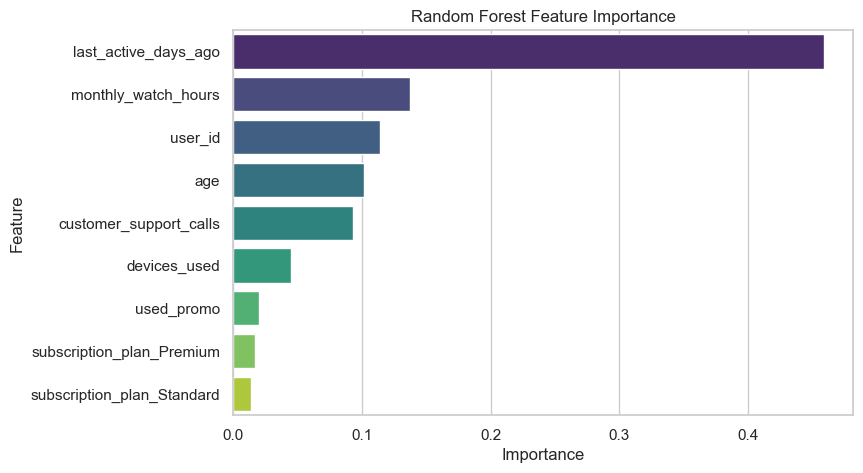

In [28]:
# Task 6: Final Report and Recommendations , Feature Importance from Random Forest 


# Create a DataFrame for feature importances
feature_importances = pd.DataFrame({
    "feature": X.columns,
    "importance": rf_clf.feature_importances_
}).sort_values(by="importance", ascending=False)

# Top 3 features
top3_features = feature_importances.head(3)
print("Top 3 factors influencing churn:")
print(top3_features)

# Plot all feature importances
plt.figure(figsize=(8,5))
sns.barplot(x="importance", y="feature", data=feature_importances, palette="viridis")
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()


## Task 6: Final Report and Recommendations

### Feature Importance (from Random Forest)
Top 3 factors influencing customer churn:
1. **last_active_days_ago** – Customers inactive for a longer period are more likely to churn.
2. **monthly_watch_hours** – Customers with low watch time tend to leave the platform.
3. **user_id** – Certain user segments (possibly based on ID grouping) show different churn rates.

---

### Conclusion
We tested two models: Logistic Regression (baseline) and Random Forest (advanced).  
Although Random Forest performed slightly better in some metrics, we chose **Logistic Regression** as our final model because:
- It provided comparable recall to Random Forest.
- It is easier to interpret and explain to business stakeholders.
- It trains faster and requires fewer computational resources.

**Final Model Performance (Logistic Regression):**
Accuracy : 0.8650
Precision: 0.7091
Recall   : 0.7800
F1 Score : 0.7429

Recall was prioritized because failing to identify a customer likely to churn (false negative) is costlier than offering retention incentives to a customer who would stay anyway (false positive).

---

### Actionable Recommendations for Streamify
1. **Re-engage inactive users**  
   Offer personalized recommendations, discounts, or reminders to users with high `last_active_days_ago` values.
   
2. **Encourage platform engagement**  
   Promote more content to customers with low `monthly_watch_hours` through targeted campaigns.
   
3. **Segment and target at-risk groups**  
   Use churn prediction results to run targeted retention offers for specific user segments before they leave.

   
